<a href="https://colab.research.google.com/github/Bhartiankita369/PW_assignment/blob/main/Data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Missing Data Identification

Scenario:
 The hospital suspects incomplete patient records.

Task:

Identify missing values in each column

Calculate percentage of missing data

In [1]:
import pandas as pd
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

#  missing values in each column
df.isnull().sum()


,0
Patient_ID,0
Age,600
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,593
Insurance_Coverage,0
Admission_Date,0


In [ ]:
# Calculate percentage of missing data
percentage_missing = (df.isnull().sum() / len(df)) * 100

print(percentage_missing)

Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64


Q2. Handling Missing Age

Scenario:
 Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median)

#### Ans:
Missing Age values are replaced using the median because age data often contains outliers, and median is robust to extreme values, ensuring more reliable imputation compared to mean.

In [ ]:
# replace missing Age with median

df['Age'].fillna(df['Age'].median())

,Age
0,35.0
1,21.0
2,77.0
3,79.0
4,60.0
...,...
5095,50.0
5096,50.0
5097,50.0
5098,50.0


Q3. Handling Missing Treatment Cost

Scenario:
 Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why.
# Ans
Since Treatment Cost is highly skewed with extreme values, median imputation is used because it is robust to outliers and provides a more representative central value compared to mean.

eg: for Treatment_Cost - 500, 800, 1000, 200000,
the mean is -  50575,
the median is - 900,
Here, mean is getting affected by expensive treatment, but median is not effected.

In [7]:
# fill missing Treatment_Cost with median

df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())


,Treatment_Cost
0,41010.0
1,12194.0
2,45086.0
3,40842.0
4,9873.0
...,...
5095,24797.0
5096,24797.0
5097,24797.0
5098,24797.0


Q4. Duplicate Patient Records

Scenario:
 Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after

In [ ]:
# Identify duplicate rows

df.duplicated().sum()

np.int64(99)

In [5]:
# Remove duplicates

cleaned = df.drop_duplicates()

print(cleaned)

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
0          17270  35.0    Male  Bangalore  Hypertension               13   
1          10860  21.0  Female  Hyderabad           Flu               11   
2          15390  77.0  Female  Bangalore        Asthma                2   
3          15191  79.0  Female     Mumbai        Asthma               13   
4          15734  60.0  Female      Delhi        Asthma                1   
...          ...   ...     ...        ...           ...              ...   
4996       16135   NaN  Female      Delhi  Hypertension               13   
4997       15573  35.0  Female      Delhi      COVID-19               19   
4998       14131  60.0  Female    Chennai  Hypertension                4   
4999       19900  16.0  Female    Chennai           Flu               16   
5095       11764   NaN  Female     Mumbai      COVID-19               15   

      Treatment_Cost  Insurance_Coverage Admission_Date  
0            41010.0         

In [6]:
# Comparison of dataset size before and after

print("Before:", df.shape)
print("After:", cleaned.shape)

Before: (5100, 9)
After: (5001, 9)


Q5. Invalid Age Values (Data Quality Check)

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them

In [ ]:
# detect invalid ages
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]

print(invalid_age)
print("Invalid count:", len(invalid_age))

Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []
Invalid count: 0


Q6. Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers

In [45]:
import numpy as np
Q1 = df["Treatment_Cost"].quantile(0.25)
Q3 = df["Treatment_Cost"].quantile(0.75)
IQR = Q3 - Q1

outlier = (df['Treatment_Cost'] < Q1 - 1.5 * IQR) | (df['Treatment_Cost'] > Q3 + 1.5 * IQR)

print(Q1)
print(Q3)
print(IQR)
print(outlier)


12498.0
37922.0
25424.0
0       False
1       False
2       False
3       False
4       False
        ...  
5095    False
5096    False
5097    False
5098    False
5099    False
Name: Treatment_Cost, Length: 5100, dtype: bool


In [36]:
# number of outliers
df[outlier]['Treatment_Cost'].count()


np.int64(50)

In [26]:
print(df.loc[outlier, 'Treatment_Cost'])

53      199702.965333
86      199702.965333
124     199702.965333
183     199702.965333
215     199702.965333
332     199702.965333
382     199702.965333
416     199702.965333
452     199702.965333
796     199702.965333
833     199702.965333
1127    199702.965333
1176    199702.965333
1219    199702.965333
1392    199702.965333
1613    199702.965333
1729    199702.965333
1771    199702.965333
2077    199702.965333
2166    199702.965333
2210    199702.965333
2228    199702.965333
2382    199702.965333
2449    199702.965333
2531    199702.965333
2561    199702.965333
2694    199702.965333
2847    199702.965333
3213    199702.965333
3279    199702.965333
3361    199702.965333
3659    199702.965333
3830    199702.965333
3855    199702.965333
3874    199702.965333
4060    199702.965333
4072    199702.965333
4207    199702.965333
4292    199702.965333
4414    199702.965333
4549    199702.965333
4582    199702.965333
4617    199702.965333
4625    199702.965333
4629    199702.965333
4656    19

Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile

In [51]:
# calculate percentiles

lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

# apply capping (winsorization)
Treatment_Cost_1 = df['Treatment_Cost'].clip(lower=lower_cap, upper=upper_cap)



In [50]:
df['Treatment_Cost_1'].count()

np.int64(4507)

Q8. Transformation

Scenario:
 Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution

In [44]:

# apply log transformation (use log1p to handle zero values)

df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

print(df[['Treatment_Cost', 'Log_Treatment_Cost']].head())

   Treatment_Cost  Log_Treatment_Cost
0         41010.0           10.621596
1         12194.0            9.408781
2         45086.0           10.716349
3         40842.0           10.617491
4          9873.0            9.197660


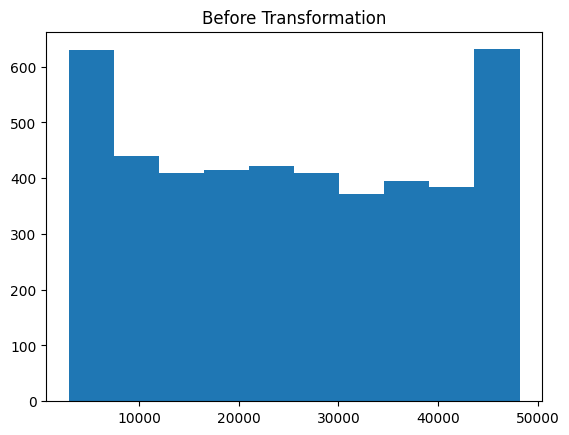

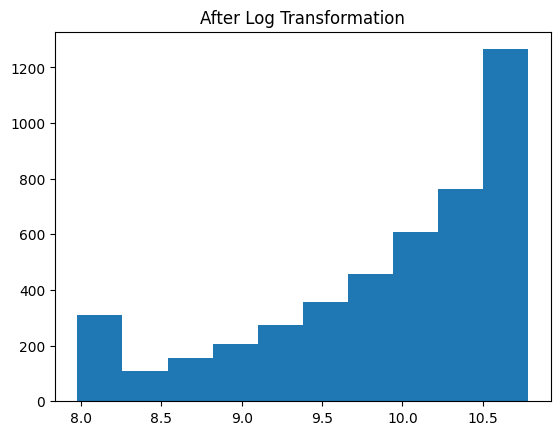

In [ ]:
import matplotlib.pyplot as plt

# before transformation
plt.hist(df['Treatment_Cost'])
plt.title("Before Transformation")
plt.show()

# after transformation
plt.hist(df['Log_Treatment_Cost'])
plt.title("After Log Transformation")
plt.show()

Q9. Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice.

# Ans
The dataset is first sorted by Admission Date to maintain chronological order. Forward fill is applied to handle missing values, as it uses previous observations and preserves the natural time sequence, which is more appropriate in healthcare data.

In [13]:

# convert to datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# sort data
df = df.sort_values(by='Admission_Date')

In [ ]:
df.fillna(method='ffill')

/tmp/ipykernel_769/1193302488.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date,Log_Treatment_Cost
2702,17230,41.0,Male,Bangalore,Hypertension,18,12398.0,0,2023-01-01,9.425371
2624,16450,57.0,Female,Chennai,Diabetes,15,39718.0,0,2023-01-01,10.589585
1791,14612,94.0,Male,Delhi,Hypertension,14,23388.0,0,2023-01-01,10.060021
4292,12430,25.0,Male,Chennai,Diabetes,11,48188.1,0,2023-01-01,10.782888
2642,19262,25.0,Female,Hyderabad,Asthma,9,48188.1,0,2023-01-01,10.782888
...,...,...,...,...,...,...,...,...,...,...
3456,19171,24.0,Female,Mumbai,Flu,1,9847.0,1,2023-12-31,9.195024
4744,12671,20.0,Female,Mumbai,COVID-19,8,22863.0,1,2023-12-31,10.037319
3013,13630,73.0,Male,Bangalore,Diabetes,3,2914.6,0,2023-12-31,7.977831
5097,19171,73.0,Female,Mumbai,Flu,1,2914.6,1,2023-12-31,7.977831
